In [ ]:
## Summary of Sentence-Level Hyperspectral Data Preparation

This notebook was written to convert raw hyperspectral sentence images into standardized PyTorch tensors that can be directly used for deep learning experiments.

The complete process ensures data consistency, correctness, and reproducibility before model training.

---

### 1. Environment Initialization and Reproducibility

All required libraries were imported for:

* File handling and dataset traversal
* Hyperspectral image processing
* Deep learning using PyTorch
* Visualization for sanity checks

A fixed random seed (SEED = 42) was set for:

* Python random
* NumPy
* PyTorch (CPU and GPU)

This guarantees that data ordering, preprocessing, and experiments remain reproducible across runs.

---

### 2. Project Directory Configuration

The project structure was defined as:

* `raw_data/` → original hyperspectral sentence folders
* `processed/` → metadata and index files
* `tensors/` → final PyTorch tensor outputs

The sentence-level index file `sentence_dataset_index.csv` was used as the single source of truth describing:

* Document
* Image
* Pen
* Sentence type
* Band count
* Image dimensions
* Absolute data path

This avoids relying on folder names during processing.

**All three main dataset folders were used:**

* `0. Pages 1 and 2`
* `1. Pages 3 and 4`
* `2. Page 5`

No data was skipped.


******how many files save in one .pt file using tensor**************




    Raw Sentence Images (Hyperspectral)
 ┌───────────┐ ┌───────────┐ ┌───────────┐
 │ Band_1.png│ │ Band_2.png│ │ Band_3.png│ … up to Band_149
 └───────────┘ └───────────┘ └───────────┘
           │
           ▼
Stack bands along spectral axis
           │
           ▼
Hyperspectral Cube (H × W × B)   ***********HEIGHT AND WEIGHT NOT SAME .... PAGE 1 2 3 4 5 VARY BASED ON TASKS..**********
 ┌───────────────┐
 │ Height × Width │
 │ × Bands = 77×515×149 │
 └───────────────┘
           │
           ▼
Convert to PyTorch Tensor
 ┌───────────────┐
 │ B × H × W = 149×78×515 │
 └───────────────┘
           │     
           ▼
Model Input (CNN / LSTM)
 ┌───────────────────────────┐
 │ Neural Network processes  │
 │ spectral & spatial info   │
 └───────────────────────────┘


### 3. Dataset Metadata Validation

The sentence index file was loaded and validated to ensure:

* Total samples: 2307 sentence samples
* Band consistency: all samples contain exactly 149 spectral bands
* Width consistency: all samples have width 515 pixels
* Sentence labels: only Sentence_1, Sentence_2, or Combined ********ALL PAGES ? 
* File existence: no missing sentence directories

These checks prevent silent errors during model training.

---

### 4. Statistical Analysis of Sentence Dimensions

Sentence heights were analyzed to understand spatial variability:

* Heights range from 42 to 78 pixels
* Majority of samples fall between 71–77 pixels
* Maximum height observed: 78 pixels

Based on this, a target height of 78 pixels was selected for padding.

This ensures:

* Uniform tensor shapes
* No spatial distortion
* Compatibility with batch-based deep learning

---

### 5. Verification of Raw Hyperspectral Structure

For a randomly selected sentence:

* All 149 band images were detected
* Bands were loaded in sorted order
* Images were confirmed as grayscale
* Pixel values ranged from 0 to 255

This confirms that each sentence folder correctly represents a hyperspectral cube.

---

### 6. Construction of Hyperspectral Cubes

For each sentence:

* Individual band images were stacked along the spectral axis
* Resulting cube shape: H × W × B (e.g., 77H × 515W × 149) ********tO VERIFY.... FOR ALL PAGES...........
* Data type initially uint8

A visual inspection of a mid-band image was performed to confirm:

* Correct spatial alignment
* No corruption or inversion

---

### 7. Preprocessing Operations

Each hyperspectral cube underwent:

1. Height Padding

   * Cubes padded to fixed height of 78 pixels
   * Preserves spatial information

2. Per-Band Normalization

   * Each spectral band independently normalized
   * Final pixel range: [0, 1]

This standardizes intensity distributions across bands and samples.

---

### 8. Conversion to PyTorch Tensor Format

Processed cubes were converted into PyTorch tensors with shape:



In [1]:
# Core
import os
import random
import numpy as np
import pandas as pd

# HSI handling
import spectral as sp

# Deep learning
import torch

# Visualization (for sanity checks later)
import matplotlib.pyplot as plt

# Progress tracking
from tqdm import tqdm


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
PROJECT_ROOT = "D:/PEC/HSI_Project"

RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "raw_data")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "processed")
TENSOR_DIR = os.path.join(PROJECT_ROOT, "tensors")

SENTENCE_INDEX_PATH = os.path.join(
    PROCESSED_DIR, "sentence_dataset_index.csv"
)

SENTENCE_TENSOR_DIR = os.path.join(
    TENSOR_DIR, "sentences"
)

os.makedirs(SENTENCE_TENSOR_DIR, exist_ok=True)


In [4]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Spectral version:", sp.__version__)

print("\nPaths check:")
print("Sentence index exists:", os.path.exists(SENTENCE_INDEX_PATH))
print("Tensor output dir:", SENTENCE_TENSOR_DIR)


Torch version: 2.5.1+cu121
CUDA available: True
Spectral version: 0.24

Paths check:
Sentence index exists: True
Tensor output dir: D:/PEC/HSI_Project\tensors\sentences


In [5]:
EXPECTED_BANDS = 149
EXPECTED_WIDTH = 515
TARGET_HEIGHT = 78   # decided from Day-1 analysis
DTYPE = np.float32


In [6]:
df = pd.read_csv(SENTENCE_INDEX_PATH)

print("Total sentence samples:", len(df))
df.head()


Total sentence samples: 2307


,page,document,image,pen,sentence,num_bands,height,width,path
0,0. Pages 1 and 2,Document_1,Image_01,Pen_1,Sentence_1,149,77,515,D:/PEC/HSI_Project\raw_data\Segregated Sentenc...
1,0. Pages 1 and 2,Document_1,Image_01,Pen_1,Sentence_2,149,78,515,D:/PEC/HSI_Project\raw_data\Segregated Sentenc...
2,0. Pages 1 and 2,Document_1,Image_01,Pen_2,Sentence_1,149,77,515,D:/PEC/HSI_Project\raw_data\Segregated Sentenc...
3,0. Pages 1 and 2,Document_1,Image_01,Pen_2,Sentence_2,149,77,515,D:/PEC/HSI_Project\raw_data\Segregated Sentenc...
4,0. Pages 1 and 2,Document_1,Image_01,Pen_3,Sentence_1,149,77,515,D:/PEC/HSI_Project\raw_data\Segregated Sentenc...


In [7]:
assert df["num_bands"].nunique() == 1, "Band count inconsistency!"
assert df["num_bands"].iloc[0] == EXPECTED_BANDS, "Unexpected band count!"

assert df["width"].nunique() == 1, "Width inconsistency!"
assert df["width"].iloc[0] == EXPECTED_WIDTH, "Unexpected width!"

print("✔ Band count and width are consistent.")


✔ Band count and width are consistent.


In [8]:
allowed_sentences = {"Sentence_1", "Sentence_2", "Combined"}
assert set(df["sentence"].unique()).issubset(allowed_sentences), "Unexpected sentence labels!"

print("✔ Sentence labels validated:", df["sentence"].unique())


✔ Sentence labels validated: ['Sentence_1' 'Sentence_2' 'Combined']


In [9]:
missing_paths = [p for p in df["path"] if not os.path.exists(p)]

print("Missing files:", len(missing_paths))


Missing files: 0


In [10]:
print("\nSentence count per type:")
print(df["sentence"].value_counts())

print("\nHeight stats:")
print(df["height"].describe())



Sentence count per type:
sentence
Combined      1011
Sentence_1     648
Sentence_2     648
Name: count, dtype: int64

Height stats:
count    2307.000000
mean       72.099697
std         7.765510
min        42.000000
25%        71.000000
50%        76.000000
75%        77.000000
max        78.000000
Name: height, dtype: float64


In [13]:
import os

sample_path = df.iloc[0]["path"]
print("Sample sentence folder:")
print(sample_path)


Sample sentence folder:
D:/PEC/HSI_Project\raw_data\Segregated Sentences and Parts\0. Pages 1 and 2\Document_1\Image_01\Pen_1\Sentence_1


In [14]:
band_files = sorted([
    f for f in os.listdir(sample_path)
    if f.lower().endswith((".png", ".jpg", ".tif"))
])

print("Total band images found:", len(band_files))
print("First 5 band files:", band_files[:5])


Total band images found: 149
First 5 band files: ['Band_1.png', 'Band_10.png', 'Band_100.png', 'Band_101.png', 'Band_102.png']


In [15]:
import cv2
import numpy as np

bands = []

for band_file in band_files:
    band_path = os.path.join(sample_path, band_file)
    img = cv2.imread(band_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load {band_path}")

    bands.append(img)


In [16]:
cube = np.stack(bands, axis=-1)


In [17]:
print("HSI Cube shape (H × W × B):", cube.shape)
print("Data type:", cube.dtype)
print("Pixel range:", cube.min(), "to", cube.max())


HSI Cube shape (H × W × B): (77, 515, 149)
Data type: uint8
Pixel range: 0 to 255


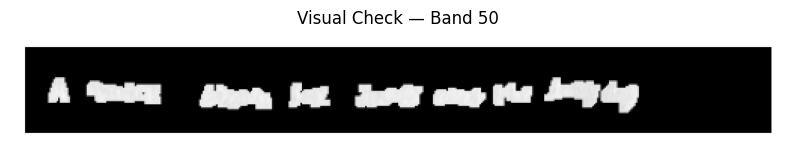

In [18]:
import matplotlib.pyplot as plt

band_index = 50  # any band between 0 and 148

plt.figure(figsize=(10, 2))
plt.imshow(cube[:, :, band_index], cmap="gray")
plt.title(f"Visual Check — Band {band_index}")
plt.axis("off")
plt.show()


In [19]:
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm


In [20]:
INDEX_CSV = "D:/PEC/HSI_Project/processed/sentence_dataset_index.csv"
RAW_ROOT = "D:/PEC/HSI_Project/raw_data"
TENSOR_OUT = "D:/PEC/HSI_Project/tensors/sentences"

os.makedirs(TENSOR_OUT, exist_ok=True)
df = pd.read_csv(INDEX_CSV)


In [21]:
TARGET_HEIGHT = 78
TARGET_WIDTH = 515
NUM_BANDS = 149


In [22]:
def load_sentence_cube(sentence_path):
    band_files = sorted(
        [f for f in os.listdir(sentence_path) if f.endswith(".png")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )

    cube = []
    for bf in band_files:
        img = Image.open(os.path.join(sentence_path, bf)).convert("L")
        cube.append(np.array(img))

    return np.stack(cube, axis=-1)  # H × W × B


In [23]:
def pad_height(cube, target_height=TARGET_HEIGHT):
    h, w, b = cube.shape
    if h == target_height:
        return cube
    padded = np.zeros((target_height, w, b), dtype=cube.dtype)
    padded[:h, :, :] = cube
    return padded


In [24]:
def normalize_per_band(cube):
    cube = cube.astype(np.float32)
    for b in range(cube.shape[2]):
        band = cube[:, :, b]
        min_val = band.min()
        max_val = band.max()
        if max_val > min_val:
            cube[:, :, b] = (band - min_val) / (max_val - min_val)
    return cube


In [25]:
saved = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):
    sentence_path = row["path"]

    cube = load_sentence_cube(sentence_path)
    cube = pad_height(cube)
    cube = normalize_per_band(cube)

    # Convert to PyTorch format: B × H × W
    tensor = torch.from_numpy(cube).permute(2, 0, 1)

    fname = f"sent_{idx:05d}.pt"
    torch.save(tensor, os.path.join(TENSOR_OUT, fname))

    saved += 1

print(f"✔ Saved {saved} sentence tensors")


100%|██████████| 2307/2307 [36:39<00:00,  1.05it/s]

✔ Saved 2307 sentence tensors


In [26]:
sample = torch.load(os.path.join(TENSOR_OUT, "sent_00000.pt"))

print("Tensor shape:", sample.shape)
print("Dtype:", sample.dtype)
print("Min / Max:", sample.min().item(), sample.max().item())


Tensor shape: torch.Size([149, 78, 515])
Dtype: torch.float32
Min / Max: 0.0 1.0


C:\Users\dell\AppData\Local\Temp\ipykernel_17292\2695999996.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load(os.path.join(TENSOR_OUT, "sent_00000.pt")